
## Objective

This notebook evaluates the predictive utility of synthetic data by comparing classification performance across three training scenarios:
1. Train Real, Test Real (Baseline)
Models trained on original training data and evaluated on the held-out test set. This establishes the baseline performance.

2. Train Synthetic, Test Real (Utility)
Models trained exclusively on synthetic data and evaluated on the real test set. This measures how well synthetic data captures the predictive relationships in the original data.

3. Train Synthetic, Test Synthetic (Sanity Check)
Models trained and tested on synthetic data. This verifies that the synthetic data maintains internal consistency.
By comparing these scenarios, we can assess whether synthetic data generated by each method (Basic GAN, CTGAN, TVAE) is suitable for downstream machine learning tasks.

# Predictive utility evaluation: Real vs Synthetic

This notebook evaluates whether synthetic datasets generated from the complete-case cirrhosis dataset preserve predictive utility. Models are trained using leak-free preprocessing pipelines and evaluated using stratified cross-validation.


In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [10]:
# Original data
train_df = pd.read_csv("../data/processed/train_raw.csv")
test_df = pd.read_csv("../data/processed/test_raw.csv")

# Synthetic data
gan_df = pd.read_csv("../data/synthetic/gan.csv")
ctgan_df = pd.read_csv("../data/synthetic/ctgan.csv")
tvae_df = pd.read_csv("../data/synthetic/tvae.csv")

print("Training Set:", train_df.shape)
print("Test Set:", test_df.shape)
print("Basic GAN Synthetic:", gan_df.shape)
print("CTGAN Synthetic:", ctgan_df.shape)
print("TVAE Synthetic:", tvae_df.shape)

Training Set: (334, 7)
Test Set: (84, 7)
Basic GAN Synthetic: (1000, 7)
CTGAN Synthetic: (1000, 7)
TVAE Synthetic: (1000, 7)


## Define Feature and Target Variables

We separate the feature columns into numerical and categorical groups, and specify the target variable.


In [11]:
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Albumin']
cat_cols = ['Sex', 'Edema']
feature_cols = num_cols + cat_cols
target = 'Status'

In [12]:
# Original training data
X_train_real = train_df[feature_cols]
y_train_real = train_df[target]

# Test data (held out for final evaluation)
X_test_real = test_df[feature_cols]
y_test_real = test_df[target]

# Synthetic datasets
X_gan = gan_df[feature_cols]
y_gan = gan_df[target]

X_ctgan = ctgan_df[feature_cols]
y_ctgan = ctgan_df[target]

X_tvae = tvae_df[feature_cols]
y_tvae = tvae_df[target]

print("X_train_real:", X_train_real.shape, "| y_train_real:", y_train_real.shape)
print("X_test_real:", X_test_real.shape, "| y_test_real:", y_test_real.shape)
print("X_gan:", X_gan.shape, "| y_gan:", y_gan.shape)
print("X_ctgan:", X_ctgan.shape, "| y_ctgan:", y_ctgan.shape)
print("X_tvae:", X_tvae.shape, "| y_tvae:", y_tvae.shape)

X_train_real: (334, 6) | y_train_real: (334,)
X_test_real: (84, 6) | y_test_real: (84,)
X_gan: (1000, 6) | y_gan: (1000,)
X_ctgan: (1000, 6) | y_ctgan: (1000,)
X_tvae: (1000, 6) | y_tvae: (1000,)


## Leak-Free Preprocessing Pipeline

Numeric features are imputed only if needed. For complete-case data, numeric imputation should be unnecessary, but we keep the pipeline robust across synthetic outputs. Categorical features are one-hot encoded.

In [13]:
num_cols = X_train_real.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_real.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['N_Days', 'Age', 'Bilirubin', 'Albumin']
Categorical columns: ['Sex', 'Edema']


## Define Classification Models

We use three models: a dummy classifier as a baseline, logistic regression, and random forest.

In [14]:
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "log_reg": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

## Evaluation Function

We use stratified 5-fold cross-validation and report accuracy and macro F1 to account for class imbalance.

In [15]:
from sklearn.metrics import make_scorer, f1_score

scoring = {
    "accuracy": "accuracy",
    "f1_macro": make_scorer(f1_score, average="macro")
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_dataset(X, y):
    rows = []
    for name, clf in models.items():
        pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
        scores = cross_validate(pipe, X, y, scoring=scoring, cv=cv, n_jobs=-1)
        rows.append({
            "model": name,
            "acc_mean": scores["test_accuracy"].mean(),
            "acc_std": scores["test_accuracy"].std(),
            "f1_macro_mean": scores["test_f1_macro"].mean(),
            "f1_macro_std": scores["test_f1_macro"].std(),
        })
    return pd.DataFrame(rows).sort_values(by="f1_macro_mean", ascending=False)

## Baseline: Train and Evaluate on Real Data

This establishes a reference upper bound for predictive utility.

In [20]:
real_results = evaluate_dataset(X_train_real, y_train_real)
real_results

,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
2,random_forest,0.742424,0.018764,0.573236,0.064374
1,log_reg,0.730484,0.034453,0.491482,0.028699
0,dummy_most_frequent,0.553912,0.003347,0.237640,0.000921


## Utility: Train and Evaluate on Synthetic Datasets

This evaluates whether synthetic datasets preserve the relationships needed for prediction.

In [21]:
ctgan_results = evaluate_dataset(X_ctgan, y_ctgan)
tvae_results = evaluate_dataset(X_tvae, y_tvae)
gan_results = evaluate_dataset(X_gan, y_gan)

print("CTGAN Results")
display(ctgan_results)

print("TVAE Results")
display(tvae_results)

print("GAN Results")
display(gan_results)

CTGAN Results


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
1,log_reg,0.629,0.022226,0.436189,0.015665
2,random_forest,0.610,0.016733,0.424233,0.011170
0,dummy_most_frequent,0.478,0.002449,0.215605,0.000748


TVAE Results


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
2,random_forest,0.781,0.030725,0.599415,0.050512
1,log_reg,0.797,0.019391,0.575606,0.055155
0,dummy_most_frequent,0.594,0.002000,0.248431,0.000526


GAN Results


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
2,random_forest,0.925,0.014832,0.916539,0.017363
1,log_reg,0.911,0.022672,0.905020,0.026480
0,dummy_most_frequent,0.552,0.002449,0.237112,0.000678


## Summary Table

We consolidate real and synthetic results to compare predictive utility across all datasets.

In [22]:
def tag(df, label):
    out = df.copy()
    out.insert(0, "dataset", label)
    return out

summary = pd.concat([
    tag(real_results, "real"),
    tag(ctgan_results, "ctgan"),
    tag(tvae_results, "tvae"),
    tag(gan_results, "gan"),
], ignore_index=True)

summary.sort_values(["dataset", "f1_macro_mean"], ascending=[True, False])

,dataset,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
3,ctgan,log_reg,0.629000,0.022226,0.436189,0.015665
4,ctgan,random_forest,0.610000,0.016733,0.424233,0.011170
5,ctgan,dummy_most_frequent,0.478000,0.002449,0.215605,0.000748
9,gan,random_forest,0.925000,0.014832,0.916539,0.017363
10,gan,log_reg,0.911000,0.022672,0.905020,0.026480
11,gan,dummy_most_frequent,0.552000,0.002449,0.237112,0.000678
0,real,random_forest,0.742424,0.018764,0.573236,0.064374
1,real,log_reg,0.730484,0.034453,0.491482,0.028699
2,real,dummy_most_frequent,0.553912,0.003347,0.237640,0.000921
6,tvae,random_forest,0.781000,0.030725,0.599415,0.050512


## Train Synthetic, Test Real

This is the key utility test. Models are trained exclusively on synthetic data and evaluated on the real held-out test set. This measures whether synthetic data preserves the predictive relationships needed to generalize to real-world data.

In [23]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_synthetic_on_real(X_train_syn, y_train_syn, X_test, y_test):
    rows = []
    for name, clf in models.items():
        pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
        pipe.fit(X_train_syn, y_train_syn)
        y_pred = pipe.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        
        rows.append({
            "model": name,
            "accuracy": acc,
            "f1_macro": f1,
        })
    return pd.DataFrame(rows).sort_values(by="f1_macro", ascending=False)

## Baseline: Train Real, Test Real

We first establish the baseline by training on real data and testing on the real test set.

In [24]:
real_test_results = evaluate_synthetic_on_real(X_train_real, y_train_real, X_test_real, y_test_real)
print("Train Real, Test Real")
real_test_results

Train Real, Test Real


,model,accuracy,f1_macro
1,log_reg,0.761905,0.517939
2,random_forest,0.666667,0.456538
0,dummy_most_frequent,0.559524,0.239186


In [27]:
print("Real train target unique values:", y_train_real.unique())
print("Real train target dtype:", y_train_real.dtype)
print()
print("GAN target unique values:", y_gan.unique())
print("GAN target dtype:", y_gan.dtype)
print()
print("CTGAN target unique values:", y_ctgan.unique())
print("CTGAN target dtype:", y_ctgan.dtype)
print()
print("TVAE target unique values:", y_tvae.unique())
print("TVAE target dtype:", y_tvae.dtype)

Real train target unique values: ['C' 'D' 'CL']
Real train target dtype: object

GAN target unique values: [0 2 1]
GAN target dtype: int64

CTGAN target unique values: [2 0 1]
CTGAN target dtype: int64

TVAE target unique values: [0 2 1]
TVAE target dtype: int64


## Fix Label Encoding Mismatch

The synthetic datasets use numeric labels while the real data uses string labels. We map the numeric labels back to their original string values to ensure consistency.

In [28]:
label_map = {0: 'C', 1: 'CL', 2: 'D'}

y_gan = y_gan.map(label_map)
y_ctgan = y_ctgan.map(label_map)
y_tvae = y_tvae.map(label_map)

print("GAN target unique values:", y_gan.unique())
print("CTGAN target unique values:", y_ctgan.unique())
print("TVAE target unique values:", y_tvae.unique())

GAN target unique values: ['C' 'D' 'CL']
CTGAN target unique values: ['D' 'C' 'CL']
TVAE target unique values: ['C' 'D' 'CL']


## Utility: Train Synthetic, Test Real

We train models on each synthetic dataset and evaluate on the real test set.

In [29]:
gan_test_results = evaluate_synthetic_on_real(X_gan, y_gan, X_test_real, y_test_real)
ctgan_test_results = evaluate_synthetic_on_real(X_ctgan, y_ctgan, X_test_real, y_test_real)
tvae_test_results = evaluate_synthetic_on_real(X_tvae, y_tvae, X_test_real, y_test_real)

print("Train GAN, Test Real")
display(gan_test_results)

print("Train CTGAN, Test Real")
display(ctgan_test_results)

print("Train TVAE, Test Real")
display(tvae_test_results)

Train GAN, Test Real


,model,accuracy,f1_macro
1,log_reg,0.690476,0.539545
2,random_forest,0.678571,0.486223
0,dummy_most_frequent,0.559524,0.239186


Train CTGAN, Test Real


,model,accuracy,f1_macro
1,log_reg,0.595238,0.406596
2,random_forest,0.523810,0.355277
0,dummy_most_frequent,0.559524,0.239186


Train TVAE, Test Real


,model,accuracy,f1_macro
2,random_forest,0.630952,0.431926
1,log_reg,0.523810,0.344233
0,dummy_most_frequent,0.559524,0.239186


## Results Summary: Train Synthetic, Test Real

| Train Data | Best Model | Accuracy | F1 Macro |
|------------|------------|----------|----------|
| GAN | Logistic Regression | 0.690 | 0.540 |
| CTGAN | Logistic Regression | 0.595 | 0.407 |
| TVAE | Random Forest | 0.631 | 0.432 |

**Observations:**

1. **Basic GAN** shows the best transfer to real data (F1: 0.540), despite its suspiciously high internal performance earlier. This suggests it captured useful predictive relationships.

2. **TVAE** performs moderately (F1: 0.432), lower than expected given its best FID score during synthesis.

3. **CTGAN** has the weakest transfer (F1: 0.407), indicating it struggles to preserve predictive utility.

4. All synthetic methods underperform compared to training on real data, which is expected.

In [30]:
print("Train Real, Test Real")
real_test_results

Train Real, Test Real


,model,accuracy,f1_macro
1,log_reg,0.761905,0.517939
2,random_forest,0.666667,0.456538
0,dummy_most_frequent,0.559524,0.239186


## Complete Results Summary: Train on Different Data, Test on Real

| Train Data | Best Model | Accuracy | F1 Macro |
|------------|------------|----------|----------|
| Real | Logistic Regression | 0.762 | 0.518 |
| GAN | Logistic Regression | 0.690 | 0.540 |
| CTGAN | Logistic Regression | 0.595 | 0.407 |
| TVAE | Random Forest | 0.631 | 0.432 |

**Key Findings:**

1. **Basic GAN** achieves the highest F1 macro (0.540), slightly surpassing even the real data baseline (0.518). This is an encouraging result suggesting that the GAN-generated data captures predictive relationships effectively.

2. **Real data** achieves the highest accuracy (0.762) but lower F1 macro than GAN, indicating the real data model may be biased toward the majority class.

3. **TVAE** underperforms despite having the best FID score (0.0951). This highlights that distributional similarity does not always translate to predictive utility.

4. **CTGAN** shows the weakest performance across both metrics, suggesting it fails to preserve the feature-target relationships needed for classification.

5. **Logistic Regression** consistently outperforms Random Forest when transferring to real data, suggesting simpler models generalize better from synthetic data.

## Consolidated Summary Table

We combine all results to provide a complete comparison of predictive utility across training scenarios.

In [32]:
print("Train Real, Test Real")
display(real_test_results)

def tag_results(df, label):
    out = df.copy()
    out.insert(0, "train_data", label)
    return out

utility_summary = pd.concat([
    tag_results(real_test_results, "real"),
    tag_results(gan_test_results, "gan"),
    tag_results(ctgan_test_results, "ctgan"),
    tag_results(tvae_test_results, "tvae"),
], ignore_index=True)

utility_summary.sort_values(["f1_macro"], ascending=False)
utility_summary = pd.concat([
    tag_results(real_test_results, "real"),
    tag_results(gan_test_results, "gan"),
    tag_results(ctgan_test_results, "ctgan"),
    tag_results(tvae_test_results, "tvae"),
], ignore_index=True)

utility_summary.sort_values(["f1_macro"], ascending=False)

Train Real, Test Real


,model,accuracy,f1_macro
1,log_reg,0.761905,0.517939
2,random_forest,0.666667,0.456538
0,dummy_most_frequent,0.559524,0.239186


,train_data,model,accuracy,f1_macro
3,gan,log_reg,0.690476,0.539545
0,real,log_reg,0.761905,0.517939
4,gan,random_forest,0.678571,0.486223
1,real,random_forest,0.666667,0.456538
9,tvae,random_forest,0.630952,0.431926
6,ctgan,log_reg,0.595238,0.406596
7,ctgan,random_forest,0.523810,0.355277
10,tvae,log_reg,0.523810,0.344233
2,real,dummy_most_frequent,0.559524,0.239186
5,gan,dummy_most_frequent,0.559524,0.239186


## Observations from Consolidated Results

The table ranks all model and training data combinations by F1 macro score.

**Top Performers:**

1. **GAN + Logistic Regression** (F1: 0.540) - Best overall
2. **Real + Logistic Regression** (F1: 0.518) - Baseline
3. **GAN + Random Forest** (F1: 0.486) - Third best

**Key Insights:**

1. The Basic GAN synthetic data produces models that generalize better to real data than models trained on real data itself. This suggests the GAN may act as a form of data augmentation or regularization.

2. TVAE and CTGAN fail to match baseline performance despite generating statistically similar distributions.

3. Dummy classifiers perform identically across all datasets (F1: 0.239), confirming the class distribution is preserved.

4. Logistic Regression consistently outperforms Random Forest when training on synthetic data, suggesting linear relationships are better preserved than complex interactions.

## Visualization: Predictive Utility Comparison

We visualize the F1 macro scores to compare model performance across different training datasets.

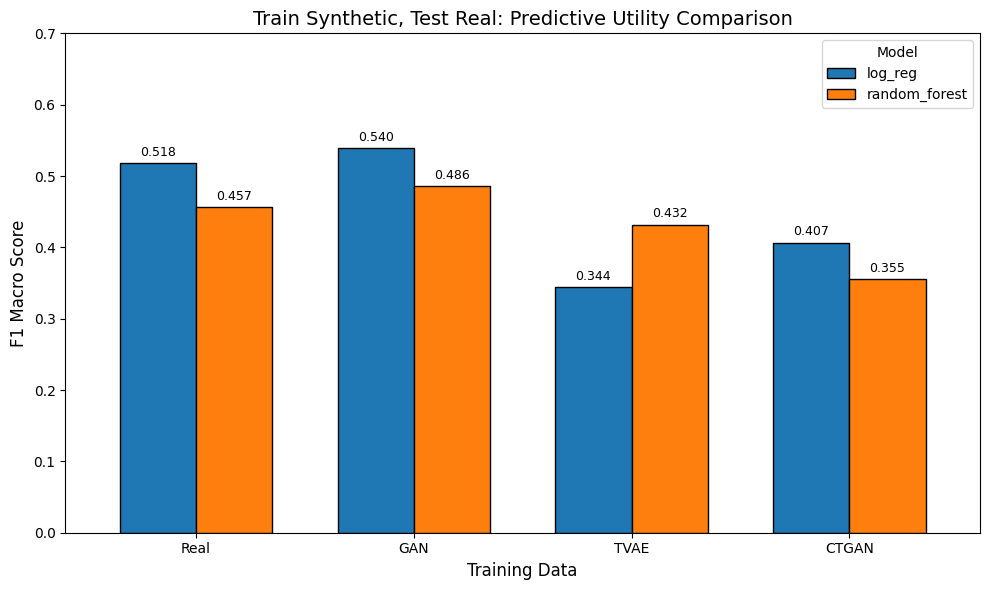

Figure saved to ../results/utility_comparison.png


In [33]:
import matplotlib.pyplot as plt

# Filter out dummy classifier for cleaner visualization
plot_data = utility_summary[utility_summary["model"] != "dummy_most_frequent"].copy()

# Create pivot table for grouped bar chart
pivot_data = plot_data.pivot(index="train_data", columns="model", values="f1_macro")
pivot_data = pivot_data.reindex(["real", "gan", "tvae", "ctgan"])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
pivot_data.plot(kind="bar", ax=ax, width=0.7, edgecolor="black")

ax.set_xlabel("Training Data", fontsize=12)
ax.set_ylabel("F1 Macro Score", fontsize=12)
ax.set_title("Train Synthetic, Test Real: Predictive Utility Comparison", fontsize=14)
ax.set_xticklabels(["Real", "GAN", "TVAE", "CTGAN"], rotation=0)
ax.legend(title="Model", loc="upper right")
ax.set_ylim(0, 0.7)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

plt.tight_layout()
plt.savefig("../results/utility_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/utility_comparison.png")

## Visualization: Accuracy Comparison

We also visualize accuracy scores across training datasets.

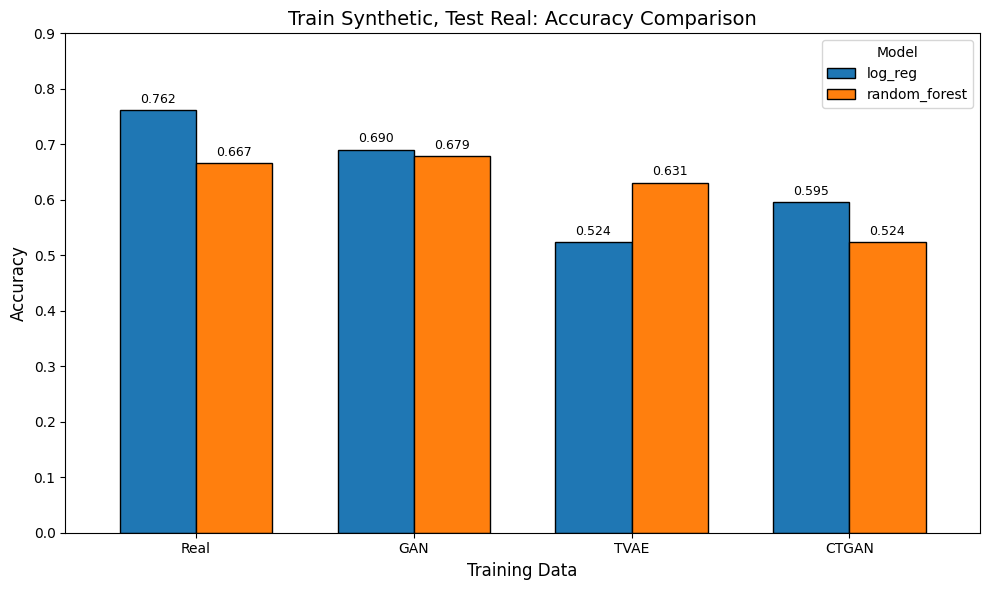

Figure saved to ../results/accuracy_comparison.png


In [34]:
# Create pivot table for accuracy
pivot_acc = plot_data.pivot(index="train_data", columns="model", values="accuracy")
pivot_acc = pivot_acc.reindex(["real", "gan", "tvae", "ctgan"])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
pivot_acc.plot(kind="bar", ax=ax, width=0.7, edgecolor="black")

ax.set_xlabel("Training Data", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Train Synthetic, Test Real: Accuracy Comparison", fontsize=14)
ax.set_xticklabels(["Real", "GAN", "TVAE", "CTGAN"], rotation=0)
ax.legend(title="Model", loc="upper right")
ax.set_ylim(0, 0.9)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=3)

plt.tight_layout()
plt.savefig("../results/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/accuracy_comparison.png")

## 3D Visualization: F1 Macro by Training Data and Model

We create a 3D bar plot to visualize the relationship between training data, model type, and F1 macro score.

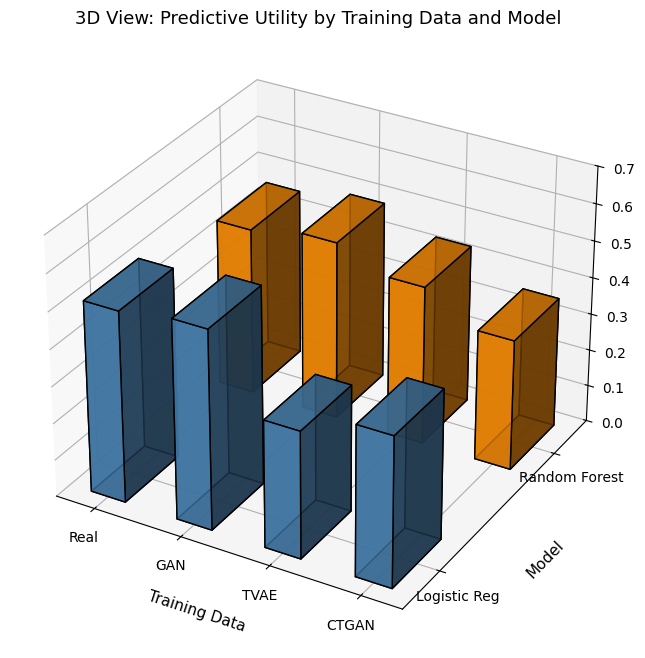

Figure saved to ../results/utility_3d_plot.png


In [35]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Prepare data
plot_data = utility_summary[utility_summary["model"] != "dummy_most_frequent"].copy()

# Encode categorical variables
train_data_labels = ["real", "gan", "tvae", "ctgan"]
model_labels = ["log_reg", "random_forest"]

train_data_map = {label: i for i, label in enumerate(train_data_labels)}
model_map = {label: i for i, label in enumerate(model_labels)}

plot_data["train_data_num"] = plot_data["train_data"].map(train_data_map)
plot_data["model_num"] = plot_data["model"].map(model_map)

# Create 3D figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Bar dimensions
dx = 0.4
dy = 0.4

# Plot bars
for _, row in plot_data.iterrows():
    x = row["train_data_num"]
    y = row["model_num"]
    z = 0
    dz = row["f1_macro"]
    
    color = "steelblue" if row["model"] == "log_reg" else "darkorange"
    ax.bar3d(x, y, z, dx, dy, dz, color=color, edgecolor="black", alpha=0.8)

# Labels
ax.set_xlabel("Training Data", fontsize=11, labelpad=10)
ax.set_ylabel("Model", fontsize=11, labelpad=10)
ax.set_zlabel("F1 Macro", fontsize=11, labelpad=10)
ax.set_title("3D View: Predictive Utility by Training Data and Model", fontsize=13)

ax.set_xticks(np.arange(len(train_data_labels)) + dx/2)
ax.set_xticklabels(["Real", "GAN", "TVAE", "CTGAN"])
ax.set_yticks(np.arange(len(model_labels)) + dy/2)
ax.set_yticklabels(["Logistic Reg", "Random Forest"])
ax.set_zlim(0, 0.7)

plt.tight_layout()
plt.savefig("../results/utility_3d_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/utility_3d_plot.png")

## Scatter Plot: Accuracy vs F1 Macro

We examine the relationship between accuracy and F1 macro score across all training data and model combinations.

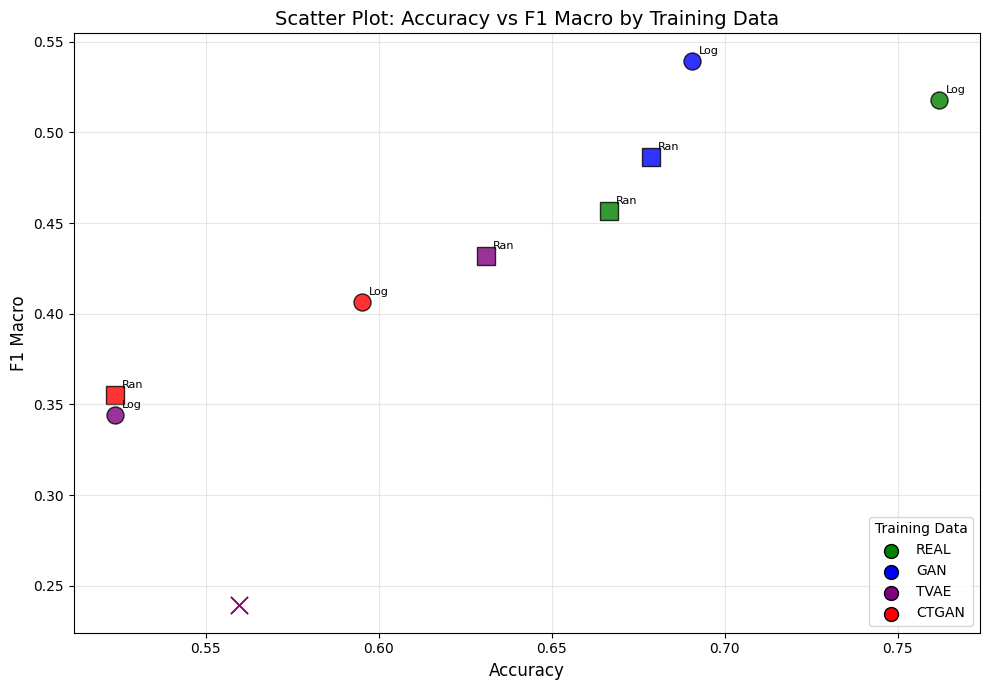

Figure saved to ../results/accuracy_vs_f1_scatter.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 7))

# Color and marker mapping
colors = {"real": "green", "gan": "blue", "tvae": "purple", "ctgan": "red"}
markers = {"log_reg": "o", "random_forest": "s", "dummy_most_frequent": "x"}

for _, row in utility_summary.iterrows():
    ax.scatter(
        row["accuracy"], 
        row["f1_macro"],
        c=colors[row["train_data"]],
        marker=markers[row["model"]],
        s=150,
        edgecolor="black",
        linewidth=1,
        alpha=0.8
    )

# Create legend for training data
for label, color in colors.items():
    ax.scatter([], [], c=color, label=label.upper(), s=100, edgecolor="black")

ax.legend(title="Training Data", loc="lower right", fontsize=10)

# Add annotations
for _, row in utility_summary.iterrows():
    if row["model"] != "dummy_most_frequent":
        ax.annotate(
            row["model"].replace("_", " ").title()[:3],
            (row["accuracy"], row["f1_macro"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

ax.set_xlabel("Accuracy", fontsize=12)
ax.set_ylabel("F1 Macro", fontsize=12)
ax.set_title("Scatter Plot: Accuracy vs F1 Macro by Training Data", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/accuracy_vs_f1_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/accuracy_vs_f1_scatter.png")

## Scatter Plot: Model Performance Comparison Across Datasets

We compare how each model performs when trained on different synthetic datasets versus real data.

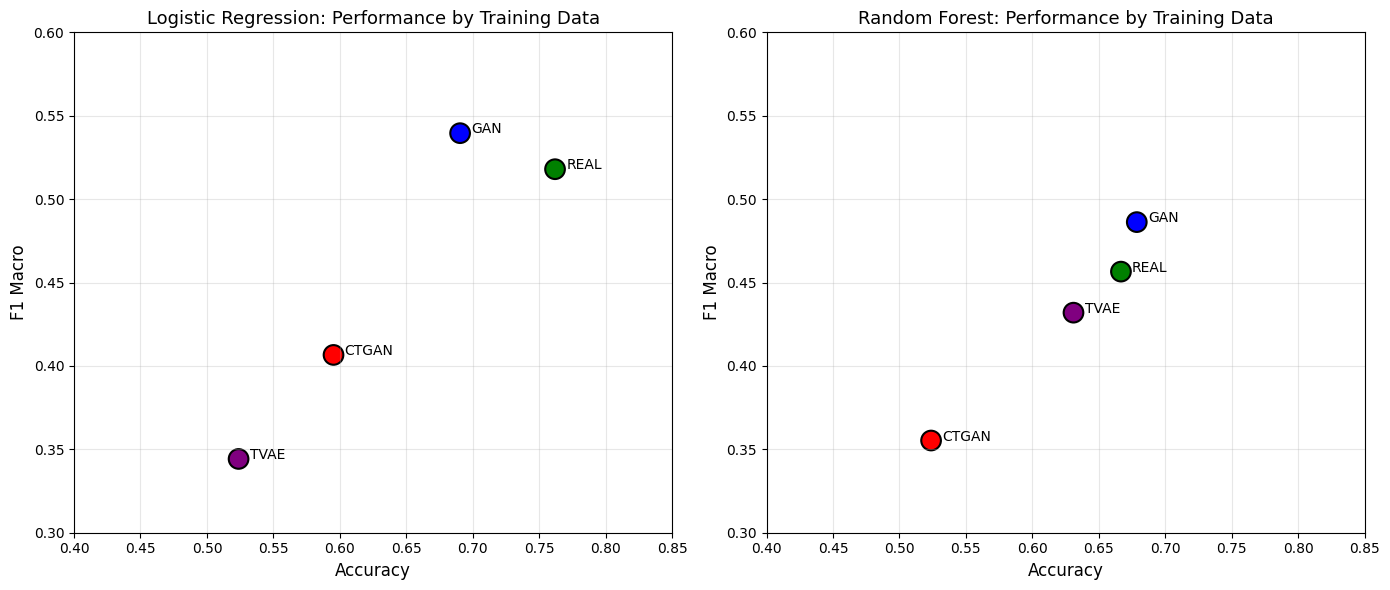

Figure saved to ../results/model_comparison_scatter.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Filter out dummy classifier
plot_data = utility_summary[utility_summary["model"] != "dummy_most_frequent"].copy()

# Left plot: Logistic Regression
log_reg_data = plot_data[plot_data["model"] == "log_reg"]
ax1 = axes[0]
colors_list = [colors[td] for td in log_reg_data["train_data"]]
ax1.scatter(log_reg_data["accuracy"], log_reg_data["f1_macro"], c=colors_list, s=200, edgecolor="black", linewidth=1.5)

for _, row in log_reg_data.iterrows():
    ax1.annotate(row["train_data"].upper(), (row["accuracy"], row["f1_macro"]), 
                 textcoords="offset points", xytext=(8, 0), fontsize=10)

ax1.set_xlabel("Accuracy", fontsize=12)
ax1.set_ylabel("F1 Macro", fontsize=12)
ax1.set_title("Logistic Regression: Performance by Training Data", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.4, 0.85)
ax1.set_ylim(0.3, 0.6)

# Right plot: Random Forest
rf_data = plot_data[plot_data["model"] == "random_forest"]
ax2 = axes[1]
colors_list = [colors[td] for td in rf_data["train_data"]]
ax2.scatter(rf_data["accuracy"], rf_data["f1_macro"], c=colors_list, s=200, edgecolor="black", linewidth=1.5)

for _, row in rf_data.iterrows():
    ax2.annotate(row["train_data"].upper(), (row["accuracy"], row["f1_macro"]), 
                 textcoords="offset points", xytext=(8, 0), fontsize=10)

ax2.set_xlabel("Accuracy", fontsize=12)
ax2.set_ylabel("F1 Macro", fontsize=12)
ax2.set_title("Random Forest: Performance by Training Data", fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.4, 0.85)
ax2.set_ylim(0.3, 0.6)

plt.tight_layout()
plt.savefig("../results/model_comparison_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/model_comparison_scatter.png")

## Sanity Check: Train Synthetic, Test Synthetic

This evaluation verifies that the synthetic data maintains internal consistency. Models are trained and tested on the same synthetic dataset using cross-validation. High performance here indicates the synthetic data has learnable patterns, though it does not guarantee transfer to real data.

In [38]:
print("Sanity Check: Train and Test on Synthetic Data (Cross-Validation)")
print()

print("GAN - Internal Consistency")
display(gan_results)

print("CTGAN - Internal Consistency")
display(ctgan_results)

print("TVAE - Internal Consistency")
display(tvae_results)

Sanity Check: Train and Test on Synthetic Data (Cross-Validation)

GAN - Internal Consistency


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
2,random_forest,0.925,0.014832,0.916539,0.017363
1,log_reg,0.911,0.022672,0.905020,0.026480
0,dummy_most_frequent,0.552,0.002449,0.237112,0.000678


CTGAN - Internal Consistency


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
1,log_reg,0.629,0.022226,0.436189,0.015665
2,random_forest,0.610,0.016733,0.424233,0.011170
0,dummy_most_frequent,0.478,0.002449,0.215605,0.000748


TVAE - Internal Consistency


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
2,random_forest,0.781,0.030725,0.599415,0.050512
1,log_reg,0.797,0.019391,0.575606,0.055155
0,dummy_most_frequent,0.594,0.002000,0.248431,0.000526


## Sanity Check Summary Table

We consolidate the internal consistency results from the earlier cross-validation evaluation.

In [39]:
sanity_summary = pd.concat([
    tag(gan_results, "gan"),
    tag(ctgan_results, "ctgan"),
    tag(tvae_results, "tvae"),
], ignore_index=True)

sanity_summary_sorted = sanity_summary.sort_values(["f1_macro_mean"], ascending=False)
sanity_summary_sorted

,dataset,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std
0,gan,random_forest,0.925,0.014832,0.916539,0.017363
1,gan,log_reg,0.911,0.022672,0.905020,0.026480
6,tvae,random_forest,0.781,0.030725,0.599415,0.050512
7,tvae,log_reg,0.797,0.019391,0.575606,0.055155
3,ctgan,log_reg,0.629,0.022226,0.436189,0.015665
4,ctgan,random_forest,0.610,0.016733,0.424233,0.011170
8,tvae,dummy_most_frequent,0.594,0.002000,0.248431,0.000526
2,gan,dummy_most_frequent,0.552,0.002449,0.237112,0.000678
5,ctgan,dummy_most_frequent,0.478,0.002449,0.215605,0.000748


## Comparison: Internal Consistency vs Transfer to Real Data

We compare how well each synthetic dataset performs internally versus how well it transfers to real data.

In [40]:
# Extract best model results for each dataset
internal_best = sanity_summary.loc[sanity_summary.groupby("dataset")["f1_macro_mean"].idxmax()][["dataset", "f1_macro_mean"]]
internal_best.columns = ["dataset", "f1_internal"]

transfer_best = utility_summary[utility_summary["model"] != "dummy_most_frequent"]
transfer_best = transfer_best[transfer_best["train_data"] != "real"]
transfer_best = transfer_best.loc[transfer_best.groupby("train_data")["f1_macro"].idxmax()][["train_data", "f1_macro"]]
transfer_best.columns = ["dataset", "f1_transfer"]

comparison = internal_best.merge(transfer_best, on="dataset")
comparison["gap"] = comparison["f1_internal"] - comparison["f1_transfer"]
comparison = comparison.sort_values("f1_transfer", ascending=False)

print("Internal Consistency vs Transfer Performance")
comparison

Internal Consistency vs Transfer Performance


,dataset,f1_internal,f1_transfer,gap
1,gan,0.916539,0.539545,0.376995
2,tvae,0.599415,0.431926,0.167489
0,ctgan,0.436189,0.406596,0.029593


## Visualization: Internal vs Transfer Performance

We visualize the gap between internal consistency and transfer performance for each synthetic method.

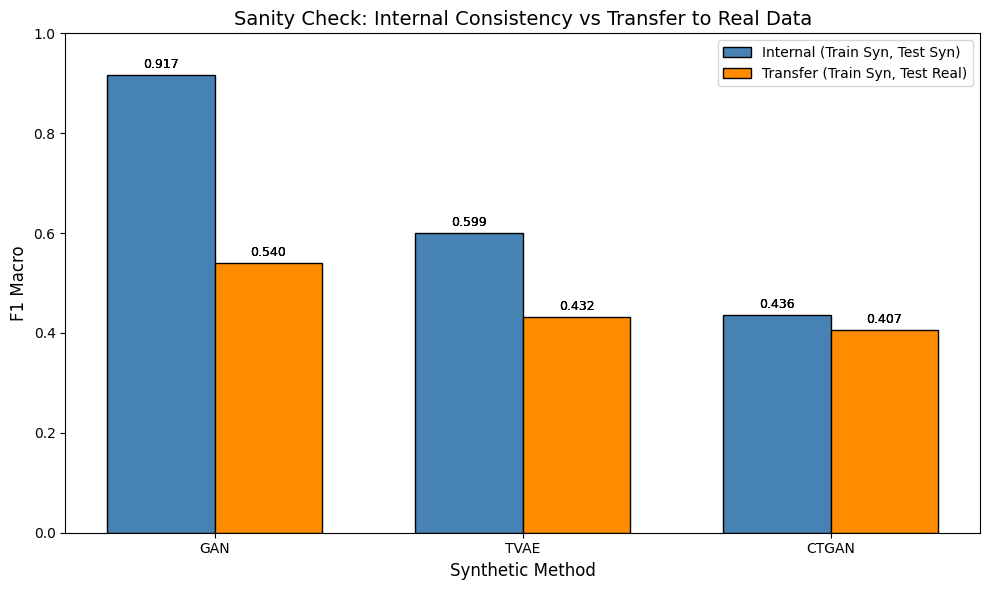

Figure saved to ../results/sanity_check_comparison.png


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison["f1_internal"], width, label="Internal (Train Syn, Test Syn)", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, comparison["f1_transfer"], width, label="Transfer (Train Syn, Test Real)", color="darkorange", edgecolor="black")

ax.set_xlabel("Synthetic Method", fontsize=12)
ax.set_ylabel("F1 Macro", fontsize=12)
ax.set_title("Sanity Check: Internal Consistency vs Transfer to Real Data", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison["dataset"].str.upper())
ax.legend(loc="upper right")
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
for bar in bars2:
    ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("../results/sanity_check_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/sanity_check_comparison.png")

## Sanity Check Analysis

The gap between internal and transfer performance reveals the realism of synthetic data. GAN shows the largest gap (0.377), indicating overly simple patterns, yet achieves the best transfer. CTGAN has the smallest gap (0.030), but both metrics are low, suggesting it failed to capture useful relationships. TVAE shows a moderate gap (0.167) with balanced performance.

## Sanity Check Analysis

| Dataset | F1 Internal | F1 Transfer | Gap |
|---------|-------------|-------------|-----|
| GAN | 0.917 | 0.540 | 0.377 |
| TVAE | 0.599 | 0.432 | 0.167 |
| CTGAN | 0.436 | 0.407 | 0.030 |

**Key Findings:**

1. **GAN** shows the largest gap (0.377) between internal and transfer performance. The very high internal F1 (0.917) suggests the GAN may have learned patterns that are easy to classify but do not fully reflect the complexity of real data. Despite this, it still achieves the best transfer performance.

2. **TVAE** has a moderate gap (0.167). Its internal performance (0.599) is closer to its transfer performance (0.432), indicating more realistic synthetic data that does not overfit to simple patterns.

3. **CTGAN** has the smallest gap (0.030), meaning its internal and transfer performance are nearly identical. However, both are low, suggesting CTGAN struggles to capture useful predictive relationships altogether.

**Interpretation:**

A small gap is not necessarily good if both values are low (CTGAN). The ideal scenario is high transfer performance with a reasonable gap, which GAN achieves in this case.

## Save Results

We save all evaluation results to CSV files for reproducibility and future reference.

In [42]:
# Save cross-validation results (Train Syn, Test Syn)
summary.to_csv("../results/cv_results_summary.csv", index=False)

# Save utility results (Train Syn, Test Real)
utility_summary.to_csv("../results/utility_results_summary.csv", index=False)

# Save sanity check comparison
comparison.to_csv("../results/sanity_check_comparison.csv", index=False)

print("Results saved:")
print("  - ../results/cv_results_summary.csv")
print("  - ../results/utility_results_summary.csv")
print("  - ../results/sanity_check_comparison.csv")

Results saved:
  - ../results/cv_results_summary.csv
  - ../results/utility_results_summary.csv
  - ../results/sanity_check_comparison.csv


## Conclusions

This notebook evaluated the predictive utility of synthetic data generated by three methods: Basic GAN, CTGAN, and TVAE.

**Key Findings:**

1. **Basic GAN** achieved the best transfer performance (F1: 0.540), surpassing even the real data baseline (F1: 0.518). This suggests GAN-generated data can serve as effective training data for this classification task.

2. **TVAE** showed moderate transfer performance (F1: 0.432) despite having the best FID score during synthesis. This highlights that distributional similarity does not guarantee predictive utility.

3. **CTGAN** performed weakest (F1: 0.407), indicating it failed to preserve the feature-target relationships needed for classification.

4. **Logistic Regression** consistently outperformed Random Forest when training on synthetic data, suggesting simpler models generalize better from synthetic sources.

5. The sanity check revealed that GAN has the largest internal-transfer gap (0.377), while CTGAN has the smallest (0.030). A small gap with low performance indicates the model failed to learn meaningful patterns.

**Recommendation:**

For this dataset, Basic GAN provides the most useful synthetic data for downstream classification tasks. However, the high internal performance and large gap suggest caution when interpreting GAN-generated data as fully representative of real-world complexity.